In [1]:
using LorenzParameterEstimation
using Plots, Random, Statistics, LinearAlgebra
using StatsBase  
using PlotlyJS
using Revise
using Plots
using Profile
using ProfileView
using ProfileCanvas

In [5]:
function plot_param_history(res_test, base_params_test)
    param_hist = res_test.param_history
    σ_hist = [p.σ for p in param_hist]
    ρ_hist = [p.ρ for p in param_hist]
    β_hist = [p.β for p in param_hist]
    epochs = 1:length(param_hist)

    σ_true = base_params_test.σ
    ρ_true = base_params_test.ρ
    β_true = base_params_test.β

    plt_σ = Plots.plot(
        epochs, σ_hist; label="σ", color=:blue, linewidth=2,
        xlabel="Epoch", ylabel="σ Value", legend=:topright,
        title="σ Evolution During Training"
    )
    Plots.hline!(plt_σ, [σ_true]; label="σ (correct)", color=:black, linestyle=:dash, linewidth=2)

    plt_ρ = Plots.plot(
        epochs, ρ_hist; label="ρ", color=:red, linewidth=2,
        xlabel="Epoch", ylabel="ρ Value", legend=:topright,
        title="ρ Evolution During Training"
    )
    Plots.hline!(plt_ρ, [ρ_true]; label="ρ (correct)", color=:black, linestyle=:dash, linewidth=2)

    plt_β = Plots.plot(
        epochs, β_hist; label="β", color=:green, linewidth=2,
        xlabel="Epoch", ylabel="β Value", legend=:topright,
        title="β Evolution During Training"
    )
    Plots.hline!(plt_β, [β_true]; label="β (correct)", color=:black, linestyle=:dash, linewidth=2)

    return Plots.plot(plt_σ, plt_ρ, plt_β, layout=(1,3), size=(1200, 350))
end


plot_param_history (generic function with 1 method)

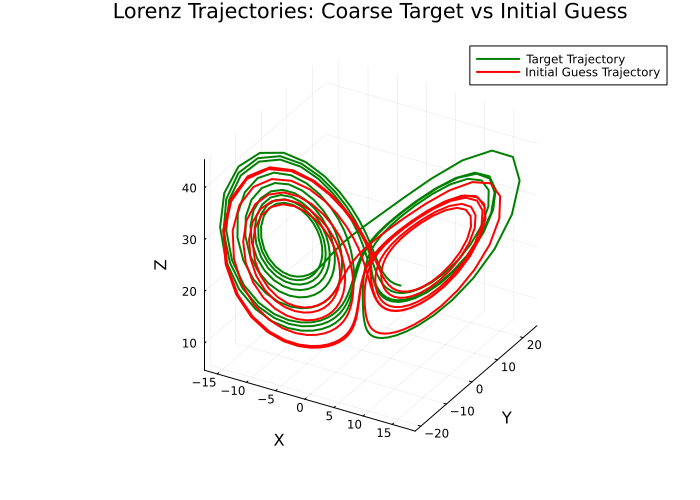

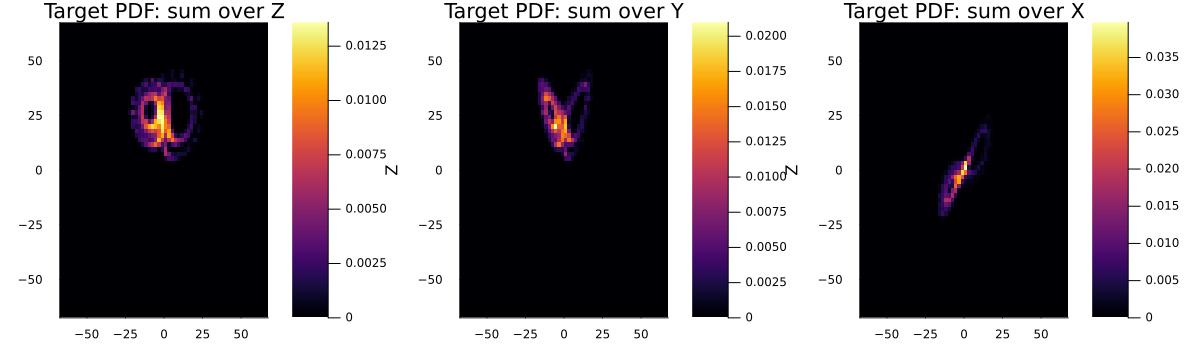

UnifiedTrain | PDF3D loss=kl | dt=0.025 steps=1200 | ICs=10 | k=200 | bins=64^3
Init  | σ=10.000000 ρ=25.000000 β=2.666667 x_s=0.000000 y_s=0.000000 z_s=0.000000 θ=1.000000
  Gradients clipped (norm 7.302e+07 > 5.00)
Epoch    1 | σ=10.000000 (Δ0.00e+00)  ρ=25.001000 (Δ1.00e-03)  β=2.666667 (Δ0.00e+00)  | loss=1.128777e+00 | g_norm=5.000e+00
  Gradients clipped (norm 2.471e+08 > 5.00)
Epoch    2 | σ=10.000000 (Δ0.00e+00)  ρ=25.002000 (Δ1.00e-03)  β=2.666667 (Δ0.00e+00)  | loss=1.087952e+00 | g_norm=5.000e+00
  Gradients clipped (norm 2.363e+08 > 5.00)
Epoch    3 | σ=10.000000 (Δ0.00e+00)  ρ=25.003000 (Δ1.00e-03)  β=2.666667 (Δ0.00e+00)  | loss=1.027091e+00 | g_norm=5.000e+00
  Gradients clipped (norm 3.088e+08 > 5.00)
Epoch    4 | σ=10.000000 (Δ0.00e+00)  ρ=25.004000 (Δ1.00e-03)  β=2.666667 (Δ0.00e+00)  | loss=1.096511e+00 | g_norm=5.000e+00
  Gradients clipped (norm 4.125e+07 > 5.00)
Epoch    5 | σ=10.000000 (Δ0.00e+00)  ρ=25.005000 (Δ1.00e-03)  β=2.666667 (Δ0.00e+00)  | loss=1.114203e

Excessive output truncated after 524413 bytes.

  Gradients clipped (norm 6.729e+08 > 5.00)
Epoch 2975 | σ=10.000000 (Δ0.00e+00)  ρ=25.715062 (Δ3.44e-04)  β=2.666667 (Δ0.00e+00)  | loss=8.282426e-01 | g_norm=5.000e+00


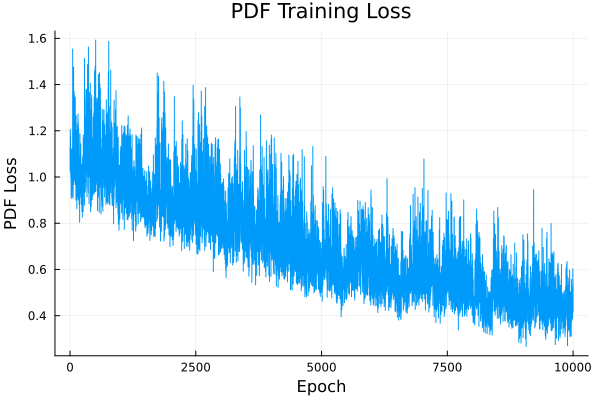

In [ ]:
using Optimisers, Random, Plots

params_classic = classic_params()
init_params = L63Parameters(σ=10.0, ρ=25.0, β=8/3)

T_coarse   = 10.0
M_coarse   = 400
u0_coarse  = Float64[1, 1, 25]
dt_coarse  = T_coarse / M_coarse
tspan_coarse = (0.0, T_coarse)

# Target trajectory (classic Lorenz)
base_params_test = classic_params()
trajectory_target = integrate(base_params_test, u0_coarse, tspan_coarse, dt_coarse)
trajectory_guess  = integrate(init_params,       u0_coarse, tspan_coarse, dt_coarse)

# Build target PDF on a moderate grid and KEEP the same h for training
xs = trajectory_target.u[:, 1]; ys = trajectory_target.u[:, 2]; zs = trajectory_target.u[:, 3]

nbins = 64  # 64 is heavy; 16–32 is fine to start
xs = trajectory_target.u[:,1]; ys = trajectory_target.u[:,2]; zs = trajectory_target.u[:,3]
hw = maximum(abs, vcat(xs, ys, zs)) * 1.50

pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=:kl)
centers = pdf_cfg.centers
Δ = (centers[end]-centers[1])/(length(centers)-1)
h = 0.5*Δ 
pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=:kl, bandwidth=h)


p3d = zeros(Float64, nbins^3)
R = max(1, ceil(Int, 3h/Δ))
soft_hist_3d_local(xs, ys, zs, centers, h, p3d; R=R)
p3d ./= sum(p3d)
target_pdf = (centers = centers, p3d = p3d)

# Multiple ICs near [1,1,25]
rng_test = MersenneTwister(42)
B_test   = 10
ics_test = [[1.0, 1.0, 25.0] .+ 0.20 .* randn(rng_test, 3) for _ in 1:B_test]
U0_test  = hcat(ics_test...)

# Constant-bandwidth schedule that EXACTLY matches pdf_cfg.h
sched = PdfSchedule{Float64}(h/Δ, h/Δ, 1.0)  # fixed bandwidth = h


cfg_test = ClimateConfig(
    dt = dt_coarse,
    steps = M_coarse * 3,
    samples_per_epoch = round(Int, 0.5*M_coarse),
    initial_conditions = U0_test,
    pdf = pdf_cfg,          # has bandwidth=h
    schedule = sched,       # forces h_curr == h
    rng = MersenneTwister(42)
)

# Plot (optional)
plt_traj = Plots.plot(
    trajectory_target.u[:,1], trajectory_target.u[:,2], trajectory_target.u[:,3];
    label="Target Trajectory", linecolor=:green, linewidth=2, seriestype=:path3d
)
Plots.plot!(
    plt_traj, trajectory_guess.u[:,1], trajectory_guess.u[:,2], trajectory_guess.u[:,3];
    label="Initial Guess Trajectory", linecolor=:red, linewidth=2, seriestype=:path3d
)
Plots.plot!(plt_traj; title="Lorenz Trajectories: Coarse Target vs Initial Guess",
    xlabel="X", ylabel="Y", zlabel="Z", legend=:topright, size=(700, 500)
)
display(plt_traj)

# Sum along each axis to get 2D marginals
m = length(centers)          # == nbins
P = reshape(p3d, m, m, m)    # (64,64,64) now
marg_xy = sum(P, dims=3)[:, :, 1]  # sum over z
marg_xz = sum(P, dims=2)[:, 1, :]  # sum over y
marg_yz = sum(P, dims=1)[1, :, :]  # sum over x

# Plot the 2D marginals
plt_xy = Plots.heatmap(centers, centers, marg_xy; xlabel="X", ylabel="Y", title="Target PDF: sum over Z")
plt_xz = Plots.heatmap(centers, centers, marg_xz; xlabel="X", ylabel="Z", title="Target PDF: sum over Y")
plt_yz = Plots.heatmap(centers, centers, marg_yz; xlabel="Y", ylabel="Z", title="Target PDF: sum over X")
plt_marginals = Plots.plot(plt_xy, plt_xz, plt_yz; layout=(1,3), size=(1200,350))

display(plt_marginals)


# Train (update only ρ). Key tweaks: smaller LR, less frequent resampling, tighter clip.
Profile.@profile begin
    res_test = train_statistics(
        init_params;
        target = target_pdf,
        stats = (:pdf3d,),
        optimizer = Optimisers.Adam(1e-3),
        update_mask = (σ=false, ρ=true, β=false, x_s=false, y_s=false, z_s=false, θ=false),
        epochs = 10_000,
        refresh = 5,
        early_stopping_patience = 1500,
        early_stopping_min_delta = 1e-6,
        rel_delta = 1e-5,
        cfg = cfg_test,
        verbose = true,
        gradient_verbose = false,
        gradient_clip_norm = 5.0,
    )
end


println("""
Parameter recovery summary:
  Initial guess:      $(init_params)
  Recovered params:   $(res_test.params)
  Target (goal):      $(base_params_test)
""")

Plots.plot(res_test.loss_history; xlabel="Epoch", ylabel="PDF Loss",
           title="PDF Training Loss", legend=false)

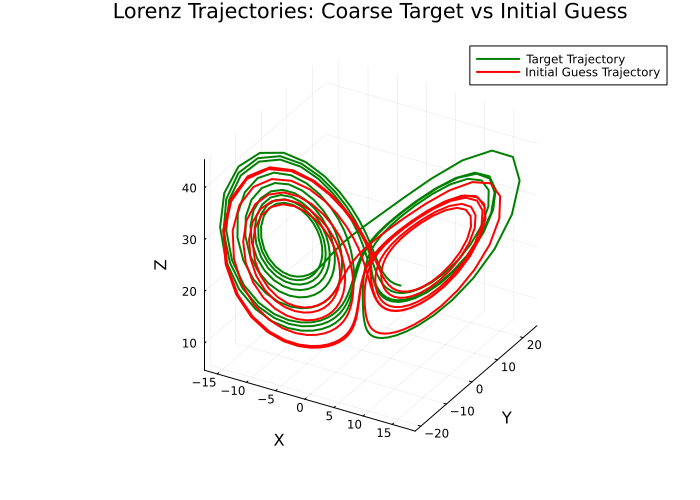

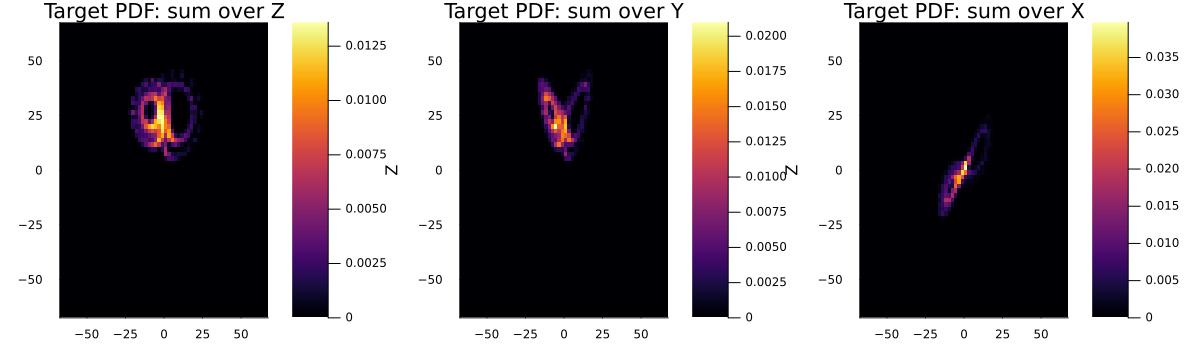

UnifiedTrain | PDF3D loss=kl | dt=0.025 steps=1200 | ICs=256 | k=200 | bins=64^3
Init  | σ=10.000000 ρ=25.000000 β=2.666667 x_s=0.000000 y_s=0.000000 z_s=0.000000 θ=1.000000
  Gradients clipped (norm 2.078e+09 > 5.00)
Epoch    1 | σ=10.000000 (Δ0.00e+00)  ρ=25.001000 (Δ1.00e-03)  β=2.666667 (Δ0.00e+00)  | loss=1.082466e+00 | g_norm=5.000e+00
  Gradients clipped (norm 1.175e+09 > 5.00)
Epoch    2 | σ=10.000000 (Δ0.00e+00)  ρ=25.002000 (Δ1.00e-03)  β=2.666667 (Δ0.00e+00)  | loss=1.096710e+00 | g_norm=5.000e+00
  Gradients clipped (norm 1.377e+09 > 5.00)
Epoch    3 | σ=10.000000 (Δ0.00e+00)  ρ=25.003000 (Δ1.00e-03)  β=2.666667 (Δ0.00e+00)  | loss=1.106314e+00 | g_norm=5.000e+00
  Gradients clipped (norm 6.390e+09 > 5.00)
Epoch    4 | σ=10.000000 (Δ0.00e+00)  ρ=25.004000 (Δ1.00e-03)  β=2.666667 (Δ0.00e+00)  | loss=1.054185e+00 | g_norm=5.000e+00
  Gradients clipped (norm 9.706e+08 > 5.00)
Epoch    5 | σ=10.000000 (Δ0.00e+00)  ρ=25.004512 (Δ5.12e-04)  β=2.666667 (Δ0.00e+00)  | loss=1.087567

Excessive output truncated after 524346 bytes.

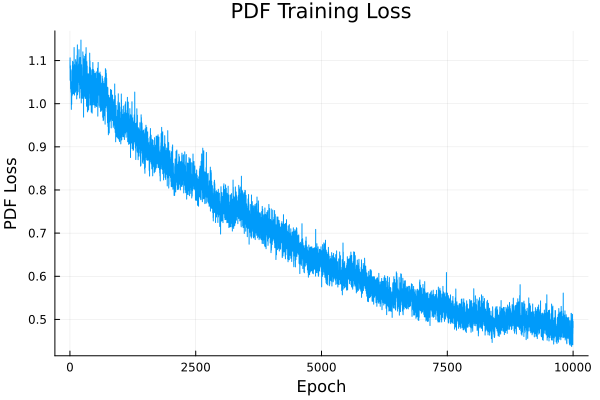

In [2]:
using Optimisers, Random, Plots

params_classic = classic_params()
init_params = L63Parameters(σ=10.0, ρ=25.0, β=8/3)

T_coarse   = 10.0
M_coarse   = 400
u0_coarse  = Float64[1, 1, 25]
dt_coarse  = T_coarse / M_coarse
tspan_coarse = (0.0, T_coarse)

# Target trajectory (classic Lorenz)
base_params_test = classic_params()
trajectory_target = integrate(base_params_test, u0_coarse, tspan_coarse, dt_coarse)
trajectory_guess  = integrate(init_params,       u0_coarse, tspan_coarse, dt_coarse)

# Build target PDF on a moderate grid and KEEP the same h for training
xs = trajectory_target.u[:, 1]; ys = trajectory_target.u[:, 2]; zs = trajectory_target.u[:, 3]

nbins = 64  # 64 is heavy; 16–32 is fine to start
xs = trajectory_target.u[:,1]; ys = trajectory_target.u[:,2]; zs = trajectory_target.u[:,3]
hw = maximum(abs, vcat(xs, ys, zs)) * 1.50

pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=:kl)
centers = pdf_cfg.centers
Δ = (centers[end]-centers[1])/(length(centers)-1)
h = 0.5*Δ 
pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=:kl, bandwidth=h)


p3d = zeros(Float64, nbins^3)
R = max(1, ceil(Int, 3h/Δ))
soft_hist_3d_local(xs, ys, zs, centers, h, p3d; R=R)
p3d ./= sum(p3d)
target_pdf = (centers = centers, p3d = p3d)

# Multiple ICs near [1,1,25]
rng_test = MersenneTwister(42)
B_test   = 256
ics_test = [[1.0, 1.0, 25.0] .+ 0.20 .* randn(rng_test, 3) for _ in 1:B_test]
U0_test  = hcat(ics_test...)

# Constant-bandwidth schedule that EXACTLY matches pdf_cfg.h
sched = PdfSchedule{Float64}(h/Δ, h/Δ, 1.0)  # fixed bandwidth = h


cfg_test = ClimateConfig(
    dt = dt_coarse,
    steps = M_coarse * 3,
    samples_per_epoch = round(Int, 0.5*M_coarse),
    initial_conditions = U0_test,
    pdf = pdf_cfg,          # has bandwidth=h
    schedule = sched,       # forces h_curr == h
    rng = MersenneTwister(42),
    batch_size = 16,               # <—— batching ON
)

# Plot (optional)
plt_traj = Plots.plot(
    trajectory_target.u[:,1], trajectory_target.u[:,2], trajectory_target.u[:,3];
    label="Target Trajectory", linecolor=:green, linewidth=2, seriestype=:path3d
)
Plots.plot!(
    plt_traj, trajectory_guess.u[:,1], trajectory_guess.u[:,2], trajectory_guess.u[:,3];
    label="Initial Guess Trajectory", linecolor=:red, linewidth=2, seriestype=:path3d
)
Plots.plot!(plt_traj; title="Lorenz Trajectories: Coarse Target vs Initial Guess",
    xlabel="X", ylabel="Y", zlabel="Z", legend=:topright, size=(700, 500)
)
display(plt_traj)

# Sum along each axis to get 2D marginals
m = length(centers)          # == nbins
P = reshape(p3d, m, m, m)    # (64,64,64) now
marg_xy = sum(P, dims=3)[:, :, 1]  # sum over z
marg_xz = sum(P, dims=2)[:, 1, :]  # sum over y
marg_yz = sum(P, dims=1)[1, :, :]  # sum over x

# Plot the 2D marginals
plt_xy = Plots.heatmap(centers, centers, marg_xy; xlabel="X", ylabel="Y", title="Target PDF: sum over Z")
plt_xz = Plots.heatmap(centers, centers, marg_xz; xlabel="X", ylabel="Z", title="Target PDF: sum over Y")
plt_yz = Plots.heatmap(centers, centers, marg_yz; xlabel="Y", ylabel="Z", title="Target PDF: sum over X")
plt_marginals = Plots.plot(plt_xy, plt_xz, plt_yz; layout=(1,3), size=(1200,350))

display(plt_marginals)


# Train (update only ρ). Key tweaks: smaller LR, less frequent resampling, tighter clip.
Profile.@profile begin
    res_test = train_statistics(
        init_params;
        target = target_pdf,
        stats = (:pdf3d,),
        optimizer = Optimisers.Adam(1e-3),
        update_mask = (σ=false, ρ=true, β=false, x_s=false, y_s=false, z_s=false, θ=false),
        epochs = 10_000,
        refresh = 5,
        early_stopping_patience = 1500,
        early_stopping_min_delta = 1e-6,
        rel_delta = 1e-5,
        cfg = cfg_test,
        verbose = true,
        gradient_verbose = false,
        gradient_clip_norm = 5.0,
    )
end

println("""
Parameter recovery summary:
  Initial guess:      $(init_params)
  Recovered params:   $(res_test.params)
  Target (goal):      $(base_params_test)
""")

Plots.plot(res_test.loss_history; xlabel="Epoch", ylabel="PDF Loss",
           title="PDF Training Loss", legend=false)

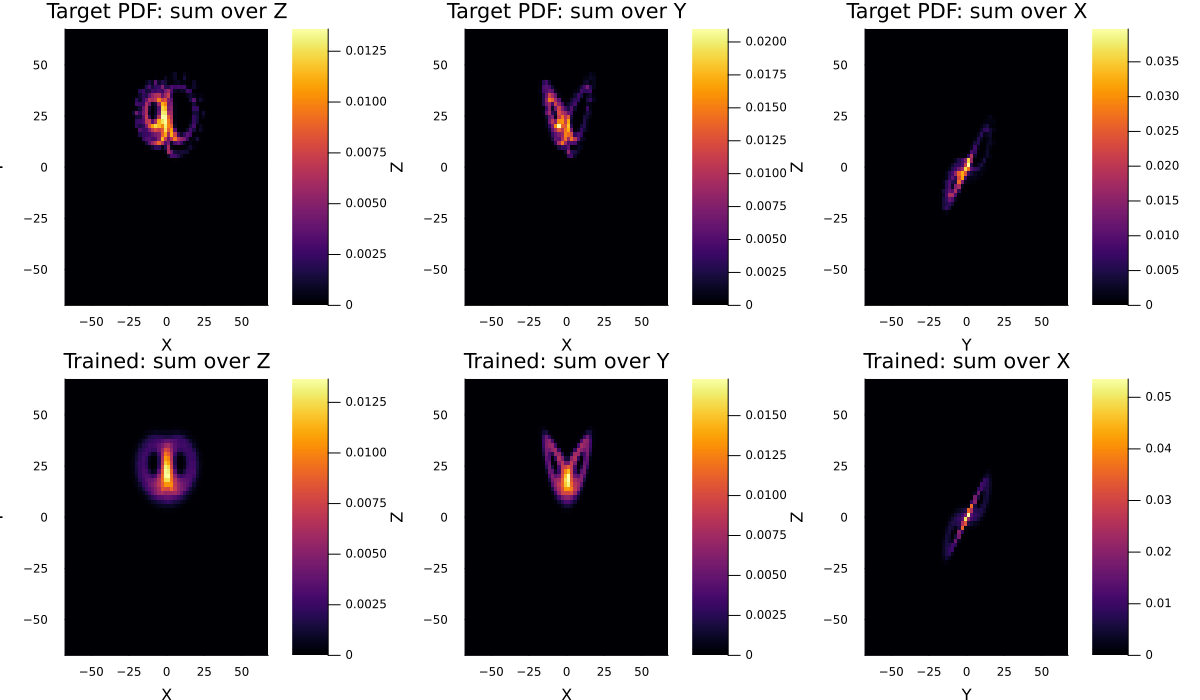

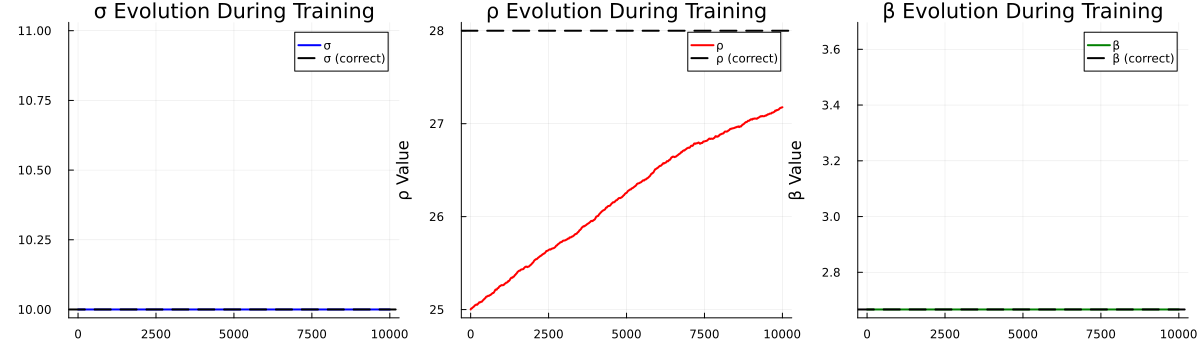

In [6]:
recovered_pdf = res_test.final_statistics[:pdf3d]
m = length(recovered_pdf.centers)
pdf = reshape(recovered_pdf.p3d, m, m, m)

# Sum along each axis to get 2D marginals for recovered PDF
marg_xy_rec = sum(pdf, dims=3)[:, :, 1]  # sum over z
marg_xz_rec = sum(pdf, dims=2)[:, 1, :]  # sum over y
marg_yz_rec = sum(pdf, dims=1)[1, :, :]  # sum over x

plt_xy_rec = Plots.heatmap(recovered_pdf.centers, recovered_pdf.centers, marg_xy_rec; xlabel="X", ylabel="Y", title="Trained: sum over Z")
plt_xz_rec = Plots.heatmap(recovered_pdf.centers, recovered_pdf.centers, marg_xz_rec; xlabel="X", ylabel="Z", title="Trained: sum over Y")
plt_yz_rec = Plots.heatmap(recovered_pdf.centers, recovered_pdf.centers, marg_yz_rec; xlabel="Y", ylabel="Z", title="Trained: sum over X")
plt_marginals_rec = Plots.plot(plt_xy_rec, plt_xz_rec, plt_yz_rec; layout=(1,3), size=(1200,350))

# Initial PDF marginals (already computed aboe)
plt_marginals_init = plt_marginals

# Stack initial and recovered marginals vertically
plt_compare = Plots.plot(plt_marginals_init, plt_marginals_rec; layout=(2,1), size=(1200,700))
display(plt_compare)

plot_params = plot_param_history(res_test, base_params_test)
display(plot_params)

# Run it for a less intensive way

In [ ]:
using Optimisers, Random, Plots

params_classic = classic_params()
init_params = L63Parameters(σ=10.0, ρ=25.0, β=8/3)

T_coarse   = 10.0
M_coarse   = 400
u0_coarse  = Float64[1, 1, 25]
dt_coarse  = T_coarse / M_coarse
tspan_coarse = (0.0, T_coarse)

# Target trajectory (classic Lorenz)
base_params_test = classic_params()
trajectory_target = integrate(base_params_test, u0_coarse, tspan_coarse, dt_coarse)
trajectory_guess  = integrate(init_params,       u0_coarse, tspan_coarse, dt_coarse)

# Build target PDF on a moderate grid and KEEP the same h for training
xs = trajectory_target.u[:, 1]; ys = trajectory_target.u[:, 2]; zs = trajectory_target.u[:, 3]

nbins = 32  # 64 is heavy; 16–32 is fine to start
xs = trajectory_target.u[:,1]; ys = trajectory_target.u[:,2]; zs = trajectory_target.u[:,3]
hw = maximum(abs, vcat(xs, ys, zs)) * 1.50

pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=:kl)
centers = pdf_cfg.centers
Δ = (centers[end]-centers[1])/(length(centers)-1)
h = 0.5*Δ 
pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=:kl, bandwidth=h)


p3d = zeros(Float64, nbins^3)
R = max(1, ceil(Int, 3h/Δ))
soft_hist_3d_local(xs, ys, zs, centers, h, p3d; R=R)
p3d ./= sum(p3d)
target_pdf = (centers = centers, p3d = p3d)

# Multiple ICs near [1,1,25]
rng_test = MersenneTwister(42)
B_test   = 128
ics_test = [[1.0, 1.0, 25.0] .+ 0.20 .* randn(rng_test, 3) for _ in 1:B_test]
U0_test  = hcat(ics_test...)

# Constant-bandwidth schedule that EXACTLY matches pdf_cfg.h
sched = PdfSchedule{Float64}(h/Δ, h/Δ, 1.0)  # fixed bandwidth = h

cfg_test = ClimateConfig(
    dt = dt_coarse,
    steps = M_coarse * 3,
    samples_per_epoch = round(Int, 0.5*M_coarse),
    initial_conditions = U0_test,
    pdf = pdf_cfg,          # has bandwidth=h
    schedule = sched,       # forces h_curr == h
    rng = MersenneTwister(42),
    batch_size = 8,              
)

# Plot (optional)
plt_traj = Plots.plot(
    trajectory_target.u[:,1], trajectory_target.u[:,2], trajectory_target.u[:,3];
    label="Target Trajectory", linecolor=:green, linewidth=2, seriestype=:path3d
)
Plots.plot!(
    plt_traj, trajectory_guess.u[:,1], trajectory_guess.u[:,2], trajectory_guess.u[:,3];
    label="Initial Guess Trajectory", linecolor=:red, linewidth=2, seriestype=:path3d
)
Plots.plot!(plt_traj; title="Lorenz Trajectories: Coarse Target vs Initial Guess",
    xlabel="X", ylabel="Y", zlabel="Z", legend=:topright, size=(700, 500)
)
display(plt_traj)

# Sum along each axis to get 2D marginals
m = length(centers)          # == nbins
P = reshape(p3d, m, m, m)    # (64,64,64) now
marg_xy = sum(P, dims=3)[:, :, 1]  # sum over z
marg_xz = sum(P, dims=2)[:, 1, :]  # sum over y
marg_yz = sum(P, dims=1)[1, :, :]  # sum over x

# Plot the 2D marginals
plt_xy = Plots.heatmap(centers, centers, marg_xy; xlabel="X", ylabel="Y", title="Target PDF: sum over Z")
plt_xz = Plots.heatmap(centers, centers, marg_xz; xlabel="X", ylabel="Z", title="Target PDF: sum over Y")
plt_yz = Plots.heatmap(centers, centers, marg_yz; xlabel="Y", ylabel="Z", title="Target PDF: sum over X")
plt_marginals = Plots.plot(plt_xy, plt_xz, plt_yz; layout=(1,3), size=(1200,350))

display(plt_marginals)


# Train (update only ρ). Key tweaks: smaller LR, less frequent resampling, tighter clip.
Profile.@profile begin
    res_test = train_statistics(
        init_params;
        target = target_pdf,
        stats = (:pdf3d,),
        optimizer = Optimisers.Adam(1e-3),
        update_mask = (σ=false, ρ=true, β=false, x_s=false, y_s=false, z_s=false, θ=false),
        epochs = 10_000,
        refresh = 5,
        early_stopping_patience = 1500,
        early_stopping_min_delta = 1e-6,
        rel_delta = 1e-5,
        cfg = cfg_test,
        verbose = true,
        gradient_verbose = false,
        gradient_clip_norm = 5.0,
    )
end

println("""
Parameter recovery summary:
  Initial guess:      $(init_params)
  Recovered params:   $(res_test.params)
  Target (goal):      $(base_params_test)
""")

Plots.plot(res_test.loss_history; xlabel="Epoch", ylabel="PDF Loss",
           title="PDF Training Loss", legend=false)